# Phase III — Robustness, Evaluation and MLOps
**ChestMNIST: pleural effusion classification under simulated label noise.**

Reuse the Phase I subset and preprocessing. Phase II selected gradient boosting, linear SVM and Gaussian Naive Bayes by validation average precision (AP). Compare each standard configuration with a fixed regularized variant, under unmodified and corrupted training labels.

Three seeds repeat the corruption/training experiment, not patient splits. Validation and test labels are unchanged. No configuration is selected using test results. MLflow tracks local runs and saves complete inference pipelines.

## 1. Environment
Select the Phase I Python environment. MLflow is an additional dependency. If missing, install it from the terminal with `phase_1/.venv/bin/python -m pip install -r phase_3/requirements.txt`. Run all cells in order.

In [1]:
from pathlib import Path
import json, time, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import sklearn
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, precision_recall_curve)

cwd = Path.cwd()
ROOT = next((p for p in (cwd,cwd.parent) if (p/'chestmnist(1)').exists()), None)
if ROOT is None: raise FileNotFoundError('Open from TP1 or phase_3.')
P1, P2 = ROOT/'phase_1'/'outputs', ROOT/'phase_2'/'outputs'
DATA, OUT = ROOT/'chestmnist(1)', ROOT/'phase_3'/'outputs'
OUT.mkdir(parents=True, exist_ok=True)
SEEDS = [42, 43, 44]
NOISE_RATE = 0.05
selected = pd.read_csv(P2/'phase3_top_three.csv')
assert set(selected.family) == {'Gradient boosting','Linear SVM','Gaussian Naive Bayes'}
assert set(selected.model) == {'Boost_depth3','LinearSVM_C0.1','GaussianNB'}
display(selected)
mlflow.set_tracking_uri('sqlite:///' + str((ROOT/'phase_3'/'mlflow.db').resolve()))
experiment_name = 'ChestMNIST_PhaseIII_MinorityLabelNoise'
experiment = mlflow.get_experiment_by_name(experiment_name)
if experiment is None:
    mlflow.create_experiment(experiment_name,
        artifact_location=(ROOT/'phase_3'/'mlartifacts').resolve().as_uri())
mlflow.set_experiment(experiment_name)
print('Tracking:', mlflow.get_tracking_uri())

2026/10/08 06:28:12 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at /home/raoul-ossombe/Desktop/2026-2027/deep learning/TP1/phase_1/.venv/lib/python3.12/site-packages/mlflow/assistant/skills/instrumenting-with-mlflow-tracing/SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


,family,model,average_precision
0,Gradient boosting,Boost_depth3,0.263275
1,Linear SVM,LinearSVM_C0.1,0.254137
2,Gaussian Naive Bayes,GaussianNB,0.244963


Tracking: sqlite:////home/raoul-ossombe/Desktop/2026-2027/deep learning/TP1/phase_3/mlflow.db


## 2. Fixed dataset and representations (Task 3.1)
Keep the original 10,000-image subset. Load Phase II's fitted scaling/PCA pipeline to preserve the representation exactly. Compute label counts and the always-absent baseline. Accuracy alone is misleading when positive cases are uncommon.

PR curves show precision versus recall across thresholds. ROC curves show recall versus false-positive rate. AP summarizes PR performance and must not be mislabeled as trapezoidal PR-AUC.

In [2]:
config = json.loads((P1/'phase1_config.json').read_text())
indices = np.load(P1/'train_indices.npy', allow_pickle=False)
preprocessing = joblib.load(P2/'preprocessing.joblib')  # trusted project artifact

def load(split):
    images = np.load(DATA/f'{split}_images.npy', mmap_mode='r', allow_pickle=False)
    labels = np.load(DATA/f'{split}_labels.npy', mmap_mode='r', allow_pickle=False)
    assert labels.shape == (len(images),14)
    return images, labels[:,2].astype(int)

def flatten(images):
    return np.asarray(images,dtype=np.float32).reshape(len(images),-1)/255.0

train_images, train_targets = load('train')
X_train, y_train = flatten(train_images[indices]), train_targets[indices]
val_images,y_val = load('val'); test_images,y_test = load('test')
Z_train = preprocessing.transform(X_train)
Z_val = preprocessing.transform(flatten(val_images))
Z_test = preprocessing.transform(flatten(test_images))
counts = np.bincount(y_train,minlength=2)
minority = int(counts.argmin())
print('Training class counts:', counts, 'minority class:', minority)
print('Validation always-absent accuracy:', float((y_val==0).mean()))
print('Test always-absent accuracy:', float((y_test==0).mean()))
print('Test positive prevalence / PR baseline:', float(y_test.mean()))
assert len(y_train) == config['actual_train']
assert minority == 1, 'Inspect ties/class changes before interpreting minority-positive corruption.'
# Phase I–II comparison and curves already cover all seven baseline families.
all_baselines = pd.read_csv(P2/'combined_test_metrics.csv')
all_baselines.to_csv(OUT/'all_baseline_test_metrics.csv',index=False)
display(all_baselines)

Training class counts: [8820 1180] minority class: 1
Validation always-absent accuracy: 0.8848382208753008
Test always-absent accuracy: 0.8772344314180003
Test positive prevalence / PR baseline: 0.12276556858199973


,phase,family,model,accuracy,precision,recall,f1,roc_auc,average_precision
0,I,Logistic regression SGA,LogReg_SGA_lr0.001,0.875362,0.340909,0.016340,0.031185,0.715165,0.250852
1,I,Gaussian Naive Bayes,GaussianNB,0.861008,0.297778,0.097313,0.146689,0.715859,0.240193
2,I,KNN,KNN_k11,0.874114,0.328431,0.024328,0.045301,0.673514,0.203074
3,II,Gradient boosting,Boost_depth3,0.877145,0.375000,0.001089,0.002172,0.731185,0.262792
4,II,Linear SVM,LinearSVM_C0.1,0.877324,0.625000,0.001816,0.003621,0.729142,0.263593
5,II,RBF SVM,RBFSVM_C1_gammascale,0.877234,0.000000,0.000000,0.000000,0.708567,0.268256
6,II,Decision tree,Tree_depth5,0.875986,0.088235,0.001089,0.002152,0.665846,0.195624


## 3. Minority-class label corruption (Task 3.2)
Select approximately 5% of minority-class training examples without replacement and flip 0 ↔ 1. This is asymmetric, class-dependent corruption, not 5% of the entire dataset. Save both subset-relative indices and original dataset indices.

For each seed, reuse exactly the same corrupted labels across all six configurations. The original arrays remain unchanged.

In [3]:
minority_indices = np.flatnonzero(y_train==minority)
n_flip = max(1, int(round(NOISE_RATE*len(minority_indices))))
noisy_targets = {}
for seed in SEEDS:
    flip = np.random.default_rng(seed).choice(minority_indices,size=n_flip,replace=False)
    corrupted = y_train.copy()
    corrupted[flip] = 1-corrupted[flip]
    assert np.count_nonzero(corrupted!=y_train) == n_flip
    assert np.array_equal(corrupted[np.setdiff1d(np.arange(len(y_train)),flip)],
                          y_train[np.setdiff1d(np.arange(len(y_train)),flip)])
    noisy_targets[seed] = corrupted
    np.save(OUT/f'flipped_subset_indices_seed{seed}.npy',flip)
    np.save(OUT/f'flipped_original_indices_seed{seed}.npy',indices[flip])
    np.save(OUT/f'noisy_train_labels_seed{seed}.npy',corrupted)
noise_description = {'minority_class':minority,'minority_count':int(counts[minority]),
    'flipped_count':n_flip,'requested_minority_noise_rate':NOISE_RATE,
    'actual_minority_noise_rate':n_flip/len(minority_indices),
    'whole_training_corruption_fraction':n_flip/len(y_train),'seeds':SEEDS}
(OUT/'noise_protocol.json').write_text(json.dumps(noise_description,indent=2))
print(noise_description)

{'minority_class': 1, 'minority_count': 1180, 'flipped_count': 59, 'requested_minority_noise_rate': 0.05, 'actual_minority_noise_rate': 0.05, 'whole_training_corruption_fraction': 0.0059, 'seeds': [42, 43, 44]}


## 4. Fixed standard and robust variants
* Boosting: standard depth 3 versus robust depth 1; same 100 trees and learning rate 0.05.
* Linear SVM: standard C=0.1 versus robust C=0.01 (stronger regularization).
* Gaussian Naive Bayes: standard var_smoothing=1e-9 versus 1e-2, adding more variance smoothing for numerical/distributional regularization.

These are hypotheses, not guaranteed improvements. Naive Bayes was selected by performance; its smoothing variant is an extension beyond the assignment's example variants. Parameters are fixed before evaluating noisy test results. Keep default decisions to compare with Phases I–II; their low recall must be reported.

In [4]:
def build_model(family, variant, seed):
    robust = variant=='robust'
    if family=='Gradient boosting':
        return GradientBoostingClassifier(n_estimators=100, learning_rate=0.05,
            max_depth=1 if robust else 3, random_state=seed)
    if family=='Linear SVM':
        return LinearSVC(C=0.01 if robust else 0.1, dual=False,
            max_iter=10000, random_state=seed)
    if family=='Gaussian Naive Bayes':
        return GaussianNB(var_smoothing=1e-2 if robust else 1e-9)
    raise ValueError(family)

def score(model, X):
    return model.decision_function(X) if hasattr(model,'decision_function') else model.predict_proba(X)[:,1]

def evaluate(y, pred, s):
    return {'accuracy':accuracy_score(y,pred),
        'precision':precision_score(y,pred,zero_division=0),
        'recall':recall_score(y,pred,zero_division=0),
        'f1':f1_score(y,pred,zero_division=0),
        'roc_auc':roc_auc_score(y,s),
        'average_precision':average_precision_score(y,s)}

## 5. Train, evaluate and log 36 runs (Task 3.3)
Three families × two variants × two label conditions × three seeds. Log validation and test metrics, all hyperparameters, label protocol and indices. Save every complete inference pipeline as an MLflow artifact. The local tracking database and artifacts are under phase_3.

Noisy labels are used only for fitting. Training times exclude the already fitted shared preprocessing. Prediction scores are ranking scores, not necessarily calibrated probabilities.

In [5]:
rows, first_seed_curves = [], {}
for seed in SEEDS:
    for family in selected.family:
        for variant in ('standard','robust'):
            for condition in ('clean','noisy'):
                model = build_model(family,variant,seed)
                y_fit = y_train if condition=='clean' else noisy_targets[seed]
                run_name = f'{family}_{variant}_{condition}_seed{seed}'
                with mlflow.start_run(run_name=run_name) as run:
                    mlflow.log_params({**model.get_params(), 'family':family,'variant':variant,
                        'condition':condition,'seed':seed,'target':'effusion','train_count':len(y_train),
                        'minority_noise_rate':0 if condition=='clean' else NOISE_RATE,
                        'flipped_count':0 if condition=='clean' else n_flip,
                        'pca_components':50,'threshold':'zero for SVM; default class rule otherwise'})
                    start=time.perf_counter(); model.fit(Z_train,y_fit)
                    fit_seconds=time.perf_counter()-start
                    mlflow.log_metric('fit_seconds',fit_seconds)
                    for split,X,y in (('validation',Z_val,y_val),('test',Z_test,y_test)):
                        pred,s=model.predict(X),score(model,X)
                        measured=evaluate(y,pred,s)
                        mlflow.log_metrics({f'{split}_{k}':float(v) for k,v in measured.items()})
                        rows.append({'family':family,'variant':variant,'condition':condition,
                            'seed':seed,'split':split,'fit_seconds':fit_seconds,
                            'mlflow_run_id':run.info.run_id,**measured})
                        if seed==SEEDS[0] and split=='test':
                            first_seed_curves[(family,variant,condition)] = s
                    pipeline=Pipeline([('preprocessing',preprocessing),('model',model)])
                    example=X_train[:3]
                    signature=infer_signature(example,pipeline.predict(example))
                    mlflow.sklearn.log_model(pipeline,name='model',signature=signature,
                                             input_example=example,
                        skops_trusted_types=['sklearn.tree._tree.Tree'])
                    mlflow.log_artifact(str(P1/'train_indices.npy'),artifact_path='protocol')
                    mlflow.log_artifact(str(OUT/'noise_protocol.json'),artifact_path='protocol')
                    if condition=='noisy':
                        mlflow.log_artifact(str(OUT/f'flipped_original_indices_seed{seed}.npy'),
                                            artifact_path='protocol')
                pd.DataFrame(rows).to_csv(OUT/'run_metrics.csv',index=False)
                print(run_name,'completed',flush=True)
results=pd.DataFrame(rows)
assert len(results)==72
assert results.mlflow_run_id.nunique()==36
display(results[results.split=='test'])

Gradient boosting_standard_clean_seed42 completed


Gradient boosting_standard_noisy_seed42 completed


Gradient boosting_robust_clean_seed42 completed


Gradient boosting_robust_noisy_seed42 completed


Linear SVM_standard_clean_seed42 completed


...

Gaussian Naive Bayes_standard_clean_seed44 completed


Gaussian Naive Bayes_standard_noisy_seed44 completed


Gaussian Naive Bayes_robust_clean_seed44 completed


Gaussian Naive Bayes_robust_noisy_seed44 completed


,family,variant,condition,seed,split,fit_seconds,mlflow_run_id,accuracy,precision,recall,f1,roc_auc,average_precision
1,Gradient boosting,standard,clean,42,test,12.234542,e3cb9d8c03d04cf28dec71dc0ad85d96,0.877145,0.416667,0.001816,0.003615,0.730933,0.262251
3,Gradient boosting,standard,noisy,42,test,11.197035,b301fea41d0e4ae4a88f00ec283fe3ba,0.877101,0.200000,0.000363,0.000725,0.731058,0.264666
5,Gradient boosting,robust,clean,42,test,3.688878,08538a6189744acfad111d69518d892e,0.877234,0.000000,0.000000,0.000000,0.702374,0.239398
7,Gradient boosting,robust,noisy,42,test,3.701090,7beb7949fce7459eaf020a24cc7387d0,0.877234,0.000000,0.000000,0.000000,0.704529,0.242737
9,Linear SVM,standard,clean,42,test,0.069581,ee6b7697d6c34ea4ac91cbac85dfb366,0.877324,0.625000,0.001816,0.003621,0.729153,0.263579
11,Linear SVM,standard,noisy,42,test,0.065510,e057f787c2f34b36a251033698790187,0.877324,0.666667,0.001452,0.002899,0.728752,0.262725
13,Linear SVM,robust,clean,42,test,0.060609,5bcdb693bffb4f6fa9013f266ef80375,0.877324,0.625000,0.001816,0.003621,0.729184,0.263581
15,Linear SVM,robust,noisy,42,test,0.104716,f8d0544e7fba41839d663697ec68bed3,0.877324,0.666667,0.001452,0.002899,0.728778,0.262676
17,Gaussian Naive Bayes,standard,clean,42,test,0.003684,21c8a9f975c4455788f409a0c51b0194,0.861053,0.298109,0.097313,0.146729,0.715877,0.240192
19,Gaussian Naive Bayes,standard,noisy,42,test,0.006359,9d13be26b9fd4b5e98a6976f092b8103,0.863950,0.303947,0.083878,0.131474,0.714934,0.241326


## 6. Paired performance drops
For AP and ROC-AUC, drop = clean score − noisy score. Positive means degradation; negative means improvement. Small fluctuations must not be described as robust superiority.

Summarize means and sample standard deviations over seeds. Since data splits are fixed and only corruption/training randomness changes, these deviations are not confidence intervals for a new patient population. Clean deterministic configurations can repeat identical results.

In [6]:
metrics=['accuracy','precision','recall','f1','roc_auc','average_precision']
summary=results.groupby(['split','family','variant','condition'])[metrics].agg(['mean','std'])
summary.columns=['_'.join(c) for c in summary.columns]
summary=summary.reset_index()
summary.to_csv(OUT/'metrics_summary.csv',index=False)
display(summary[summary.split=='test'])

test=results[results.split=='test']
clean=test[test.condition=='clean'].set_index(['family','variant','seed'])
noisy=test[test.condition=='noisy'].set_index(['family','variant','seed'])
drops=(clean[metrics]-noisy[metrics]).add_suffix('_drop').reset_index()
drops.to_csv(OUT/'paired_performance_drops.csv',index=False)
drop_summary=drops.groupby(['family','variant'])[[m+'_drop' for m in metrics]].agg(['mean','std'])
drop_summary.columns=['_'.join(c) for c in drop_summary.columns]
drop_summary=drop_summary.reset_index()
drop_summary.to_csv(OUT/'drop_summary.csv',index=False)
display(drop_summary[['family','variant','average_precision_drop_mean',
                     'average_precision_drop_std','roc_auc_drop_mean']])
comparison=drops.pivot(index=['family','seed'],columns='variant',values='average_precision_drop')
comparison['robust_drop_reduction']=comparison['standard']-comparison['robust']
comparison.reset_index().to_csv(OUT/'robust_drop_comparison.csv',index=False)
print('Positive robust_drop_reduction means a smaller AP drop for the robust variant.')
display(comparison)

,split,family,variant,condition,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std
0,test,Gaussian Naive Bayes,robust,clean,0.870414,0.000000,0.328090,0.000000,0.053014,0.000000,0.091279,0.000000,0.726881,0.000000,0.251671,0.000000
1,test,Gaussian Naive Bayes,robust,noisy,0.871321,0.000303,0.321418,0.004395,0.043331,0.001275,0.076360,0.001967,0.725452,0.001650,0.250913,0.001872
2,test,Gaussian Naive Bayes,standard,clean,0.861053,0.000000,0.298109,0.000000,0.097313,0.000000,0.146729,0.000000,0.715877,0.000000,0.240192,0.000000
3,test,Gaussian Naive Bayes,standard,noisy,0.862583,0.001224,0.295595,0.007770,0.086178,0.004301,0.133396,0.005096,0.712306,0.002890,0.238330,0.002887
4,test,Gradient boosting,robust,clean,0.877234,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.702374,0.000000,0.239398,0.000000
5,test,Gradient boosting,robust,noisy,0.877234,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.702207,0.002147,0.240372,0.002062
6,test,Gradient boosting,standard,clean,0.877145,0.000000,0.416667,0.000000,0.001816,0.000000,0.003615,0.000000,0.730814,0.000104,0.262254,0.000036
7,test,Gradient boosting,standard,noisy,0.877190,0.000077,0.400000,0.173205,0.000847,0.000839,0.001690,0.001670,0.729352,0.001488,0.262903,0.001968
8,test,Linear SVM,robust,clean,0.877324,0.000000,0.625000,0.000000,0.001816,0.000000,0.003621,0.000000,0.729184,0.000000,0.263581,0.000000
9,test,Linear SVM,robust,noisy,0.877279,0.000045,0.588889,0.083887,0.001210,0.000210,0.002416,0.000418,0.728928,0.000155,0.262364,0.000592


,family,variant,average_precision_drop_mean,average_precision_drop_std,roc_auc_drop_mean
0,Gaussian Naive Bayes,robust,0.000758,0.001872,0.001429
1,Gaussian Naive Bayes,standard,0.001862,0.002887,0.003570
2,Gradient boosting,robust,-0.000974,0.002062,0.000167
3,Gradient boosting,standard,-0.000649,0.001993,0.001462
4,Linear SVM,robust,0.001217,0.000592,0.000256
5,Linear SVM,standard,0.001184,0.000615,0.000256


Positive robust_drop_reduction means a smaller AP drop for the robust variant.


variant                      robust  standard  robust_drop_reduction
family               seed                                           
Gaussian Naive Bayes 42   -0.001397 -0.001134               0.000263
                     43    0.001689  0.002094               0.000405
                     44    0.001983  0.004627               0.002644
Gradient boosting    42   -0.003339 -0.002415               0.000924
                     43    0.000449  0.001512               0.001063
                     44   -0.000032 -0.001044              -0.001012
Linear SVM           42    0.000904  0.000854              -0.000050
                     43    0.000846  0.000803              -0.000043
                     44    0.001900  0.001894              -0.000006

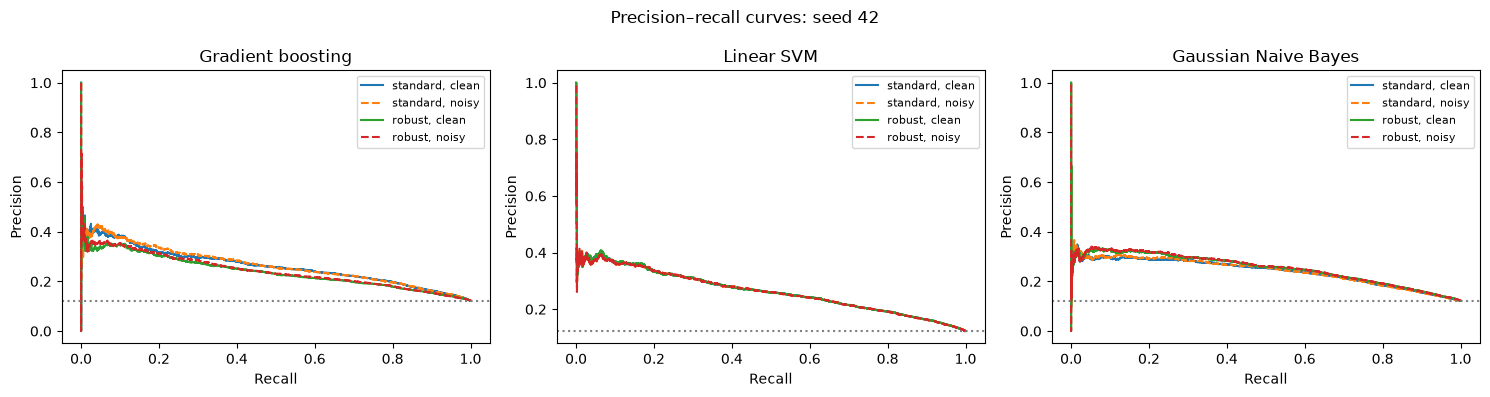

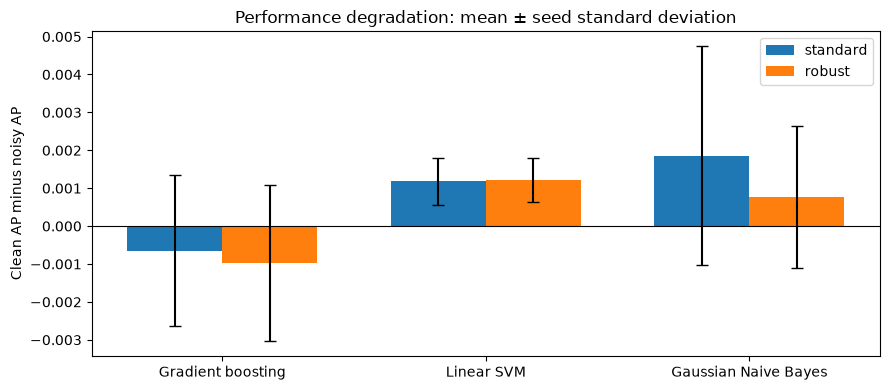

In [7]:
fig,axes=plt.subplots(1,3,figsize=(15,4))
for ax,family in zip(axes,selected.family):
    for variant in ('standard','robust'):
        for condition in ('clean','noisy'):
            s=first_seed_curves[(family,variant,condition)]
            p,r,_=precision_recall_curve(y_test,s)
            ax.plot(r,p,linestyle='-' if condition=='clean' else '--',
                    label=f'{variant}, {condition}')
    ax.axhline(y_test.mean(),linestyle=':',color='gray')
    ax.set(xlabel='Recall',ylabel='Precision',title=family)
    ax.legend(fontsize=8)
fig.suptitle('Precision–recall curves: seed 42')
fig.tight_layout(); fig.savefig(OUT/'robustness_pr_curves.png',dpi=150); plt.show()

fig,ax=plt.subplots(figsize=(9,4))
positions=np.arange(len(selected))
for offset,variant in ((-0.18,'standard'),(0.18,'robust')):
    sub=drop_summary.set_index(['family','variant'])
    means=[sub.loc[(f,variant),'average_precision_drop_mean'] for f in selected.family]
    stds=[sub.loc[(f,variant),'average_precision_drop_std'] for f in selected.family]
    ax.bar(positions+offset,means,width=0.36,yerr=stds,capsize=4,label=variant)
ax.axhline(0,color='black',linewidth=0.8)
ax.set_xticks(positions,selected.family)
ax.set(ylabel='Clean AP minus noisy AP',title='Performance degradation: mean ± seed standard deviation')
ax.legend(); fig.tight_layout(); fig.savefig(OUT/'average_precision_drops.png',dpi=150); plt.show()

## 7. Final experiment artifacts and interpretation
Report the measured AP drops and the absolute noisy-label performance together. A small drop does not necessarily mean a strong classifier. Continue to disclose near-zero recall at default thresholds. Class imbalance, low resolution and label annotation noise limit interpretation.

The required 5% minority corruption represents a much smaller fraction of the whole dataset. It may produce small effects; do not invent a degradation or claim significance from only three repetitions.

For the article, use all_baseline_test_metrics.csv, metrics_summary.csv, drop_summary.csv and the figures. For MLflow inspection, run from TP1:
`phase_1/.venv/bin/python -m mlflow ui --backend-store-uri sqlite:///phase_3/mlflow.db --host 127.0.0.1 --port 5000`
Then open http://127.0.0.1:5000. The database and mlartifacts directory must stay together; do not commit tracking files to Git by default. Raw CSV tables and plots can be shared.

In [8]:
versions={'python':sys.version,'numpy':np.__version__,'scikit_learn':sklearn.__version__,
    'mlflow':mlflow.__version__,'seed_repetitions':SEEDS,'selection':'Phase II validation AP',
    'preprocessing':'fixed Phase II training-fitted scaler and PCA(50)',
    'fit_seconds_scope':'model fit only','test_used_for_tuning':False}
(OUT/'phase3_config.json').write_text(json.dumps(versions,indent=2))
with mlflow.start_run(run_name='PhaseIII_summary'):
    mlflow.log_params({'training_runs':36,'seed_repetitions':3,'minority_noise_rate':NOISE_RATE})
    for name in ('metrics_summary.csv','paired_performance_drops.csv','drop_summary.csv',
                 'robust_drop_comparison.csv','all_baseline_test_metrics.csv',
                 'phase3_config.json','robustness_pr_curves.png','average_precision_drops.png'):
        mlflow.log_artifact(str(OUT/name),artifact_path='summary')
print('Phase III complete. Outputs:',OUT.resolve())

Phase III complete. Outputs: /home/raoul-ossombe/Desktop/2026-2027/deep learning/TP1/phase_3/outputs
